In [ ]:
import nbformat, base64, re
from pathlib import Path

nb_file = "ee22b002_1.ipynb"

# Load notebook
nb = nbformat.read(nb_file, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "markdown":
        matches = re.findall(r'!\[\]\((.*?)\)', cell.source)
        for img_path in matches:
            path = Path(img_path)
            if path.exists():
                ext = path.suffix[1:]  # e.g., 'jpg' or 'png'
                data = base64.b64encode(path.read_bytes()).decode()
                img_tag = f'<img src="data:image/{ext};base64,{data}">'
                cell.source = cell.source.replace(f"![]({img_path})", img_tag)

# Save notebook with embedded images
nbformat.write(nb, "my_notebook_embedded.ipynb")


# Assignment 1

1. Consider the following integral: $$I_n = \displaystyle \int_0^1 x^{2n} \sin(\pi x) dx$$
    * Obtain a recurrence for $I_n$ in terms of $I_{n-1}$. (HINT: Integration by parts)
    * Evaluate $I_0$ by hand
    * Use the recurrence to obtain $I_n$ for $n \in \{1,2,\ldots,20\}$ in python.
    * Obtain the integral using the builtin <code style="color : blue">scipy.integrate.quad</code> command in python and compare the results to above.
    * Explain your observation. We will see later in this course how to evaluate integrals to high accuracy.

#Q1
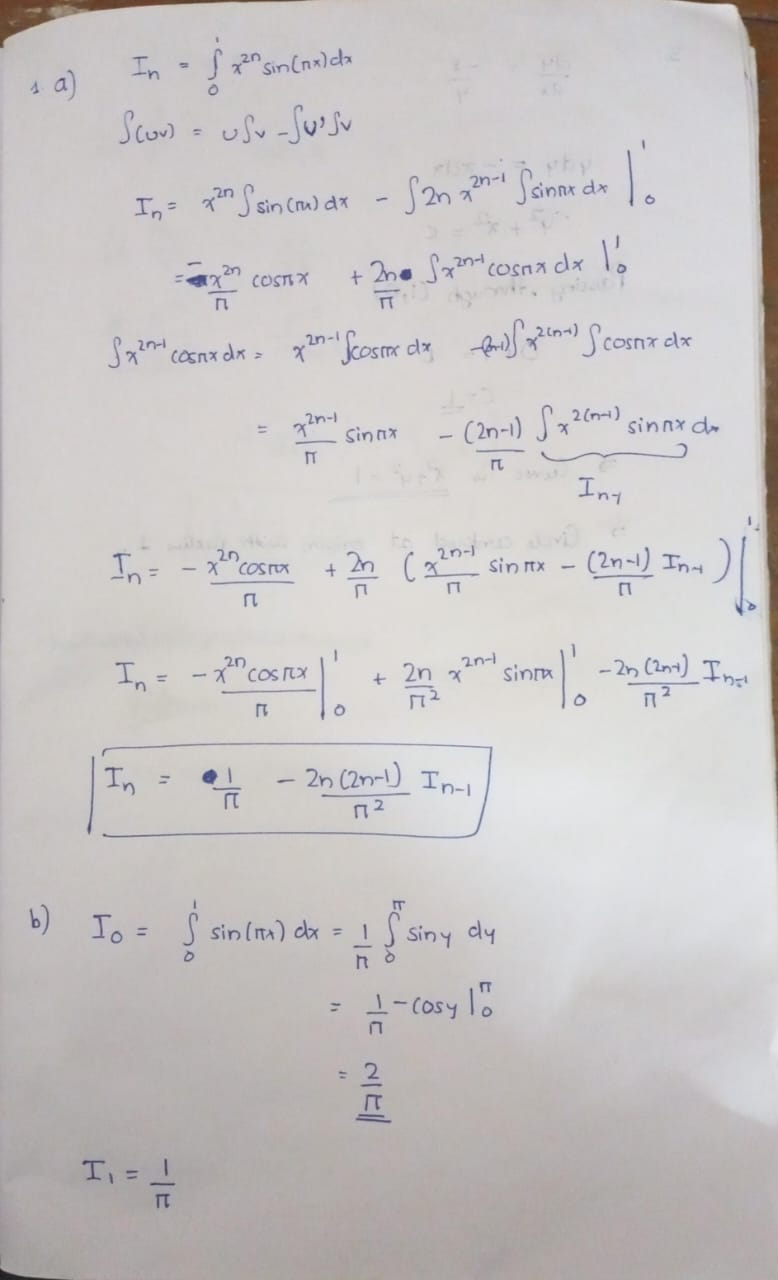

In [ ]:
import numpy as np
from scipy.integrate import quad
import math

# Using scipy.integrate,quad
def I_n_quad(n):
    integrand = lambda x: x**(2*n) * np.sin(np.pi * x)
    result, _ = quad(integrand, 0, 1)
    return result

# Recurrence relation obtained
def I_n_recurrence(n):
    if n == 0:
        return 2 / (np.pi)
    return (1/np.pi) - (2*n*(2*n - 1)/(np.pi**2)) *I_n_recurrence(n - 1)

# Compare both for n = 1 to 20
print(f"{'n':<3} {'I_n (quad)':<20} {'I_n (recurrence)':<20} {'Abs Error':<20}")
for n in range(1,20):
    val_quad = I_n_quad(n)
    val_rec = I_n_recurrence(n)
    error = abs(val_quad - val_rec)
    print(f"{n:<3} {val_quad:<20.15f} {val_rec:<20.15f} {error:<20.2e}")


n   I_n (quad)           I_n (recurrence)     Abs Error           
1   0.189303748450993    0.189303748450993    2.78e-17            
2   0.088144127851959    0.088144127851959    1.39e-17            
3   0.050383865231329    0.050383865231329    4.16e-17            
4   0.032432525927793    0.032432525927793    1.80e-16            
5   0.022560713787459    0.022560713787457    1.86e-15            
6   0.016573960515287    0.016573960515312    2.47e-14            
7   0.012678506120642    0.012678506120186    4.56e-13            
8   0.010005586913372    0.010005586924461    1.11e-11            
9   0.008093845999443    0.008093845655660    3.44e-10            
10  0.006680224568479    0.006680237804839    1.32e-08            
11  0.005605989936787    0.005605370337628    6.20e-07            
12  0.004770830376769    0.004805484119880    3.47e-05            
13  0.004108868708635    0.001826615833327    2.28e-03            
14  0.003575412795450    0.178393278194615    1.75e-01        

**Explanation**: The recurrence relation fails for higher orders beyond n=11. The mostly likely cause for this is that the python operations have finite precision. For large number of recursions, the error blows up exponentially. It may be noted that. the scipy quad optimizer may be treated as the ground-truth due to its high reliability and accuracy in numerical integration.

2. Solve the following differential equations:
* $xy'+y = x^3y^6$
* $xy^2y'+y^3 = x \cos(x)$
* $xy'+y = y^2 \cos(x)$
* $(x^2y^3+xy)y' = 1$
* $y' + (2x\arctan(y)-x^3)(1+y^2) = 0$
* $(x^2+y)dx+(y^3+x)dy = 0$
* $(1+\exp(x/y))dx + \exp(x/y)(1-x/y)dy = 0$
* $(y^2 e^{x y^2} + 4x^3)dx + (2x y e^{x y^2} - 3y^2)dy = 0$
* $(x\,dx + y\,dy)(x^2 + y^2) = y\,dx - x\,dy$
* $y \cos(x)dx + 2 \sin(x)dy = 0$
* $x\,dy + y\,dx + 3x^3 y^4 dy = 0$
* $(1 + xy)y\,dx + (1 - xy)x\,dy = 0$
* $(y^4 + 2y)dx + (x y^3 + 2y^4 - 4x)dy = 0$
* $(xy - 1)dx + (x^2 - xy)dy = 0$

# Q2a

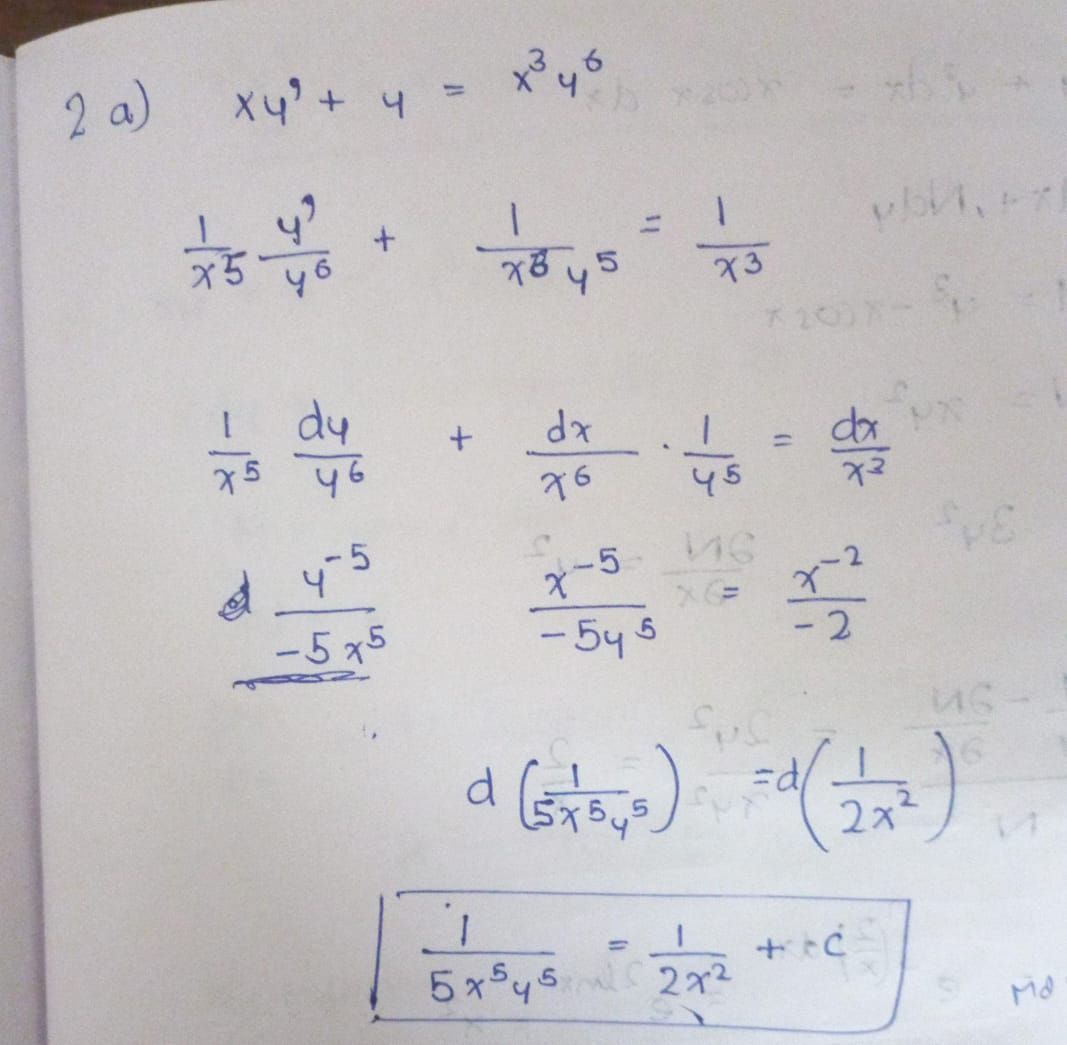

# Q2b

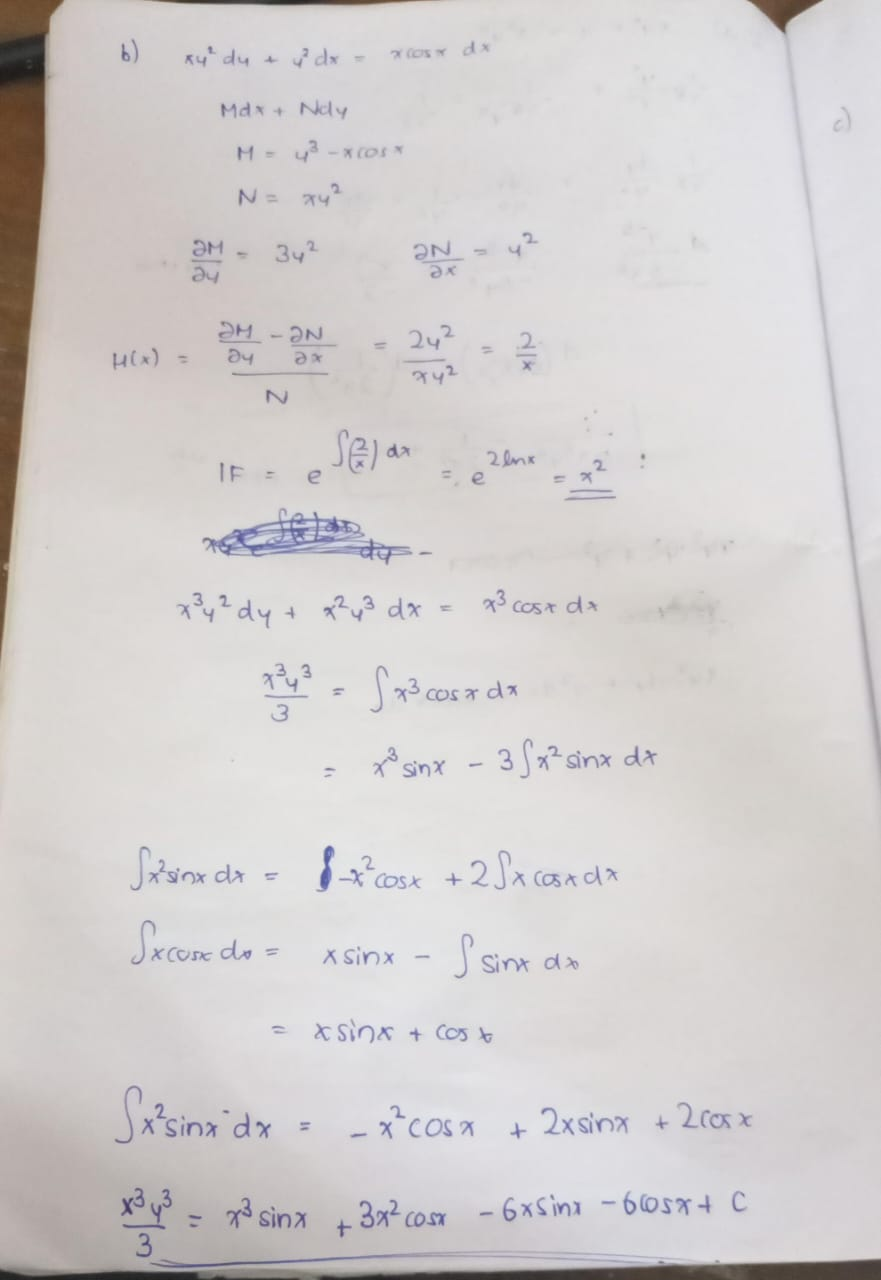

# Q2c

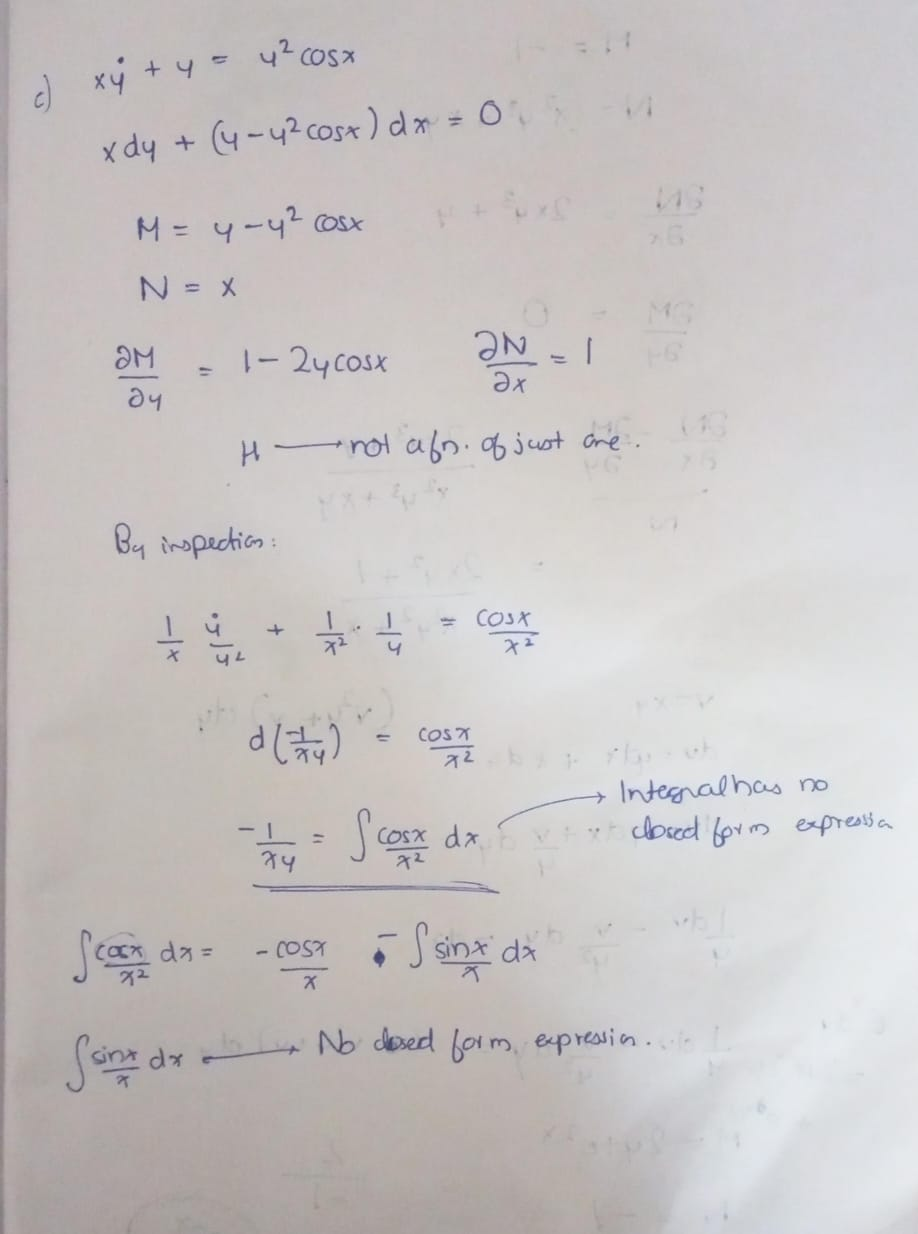

# Q2d

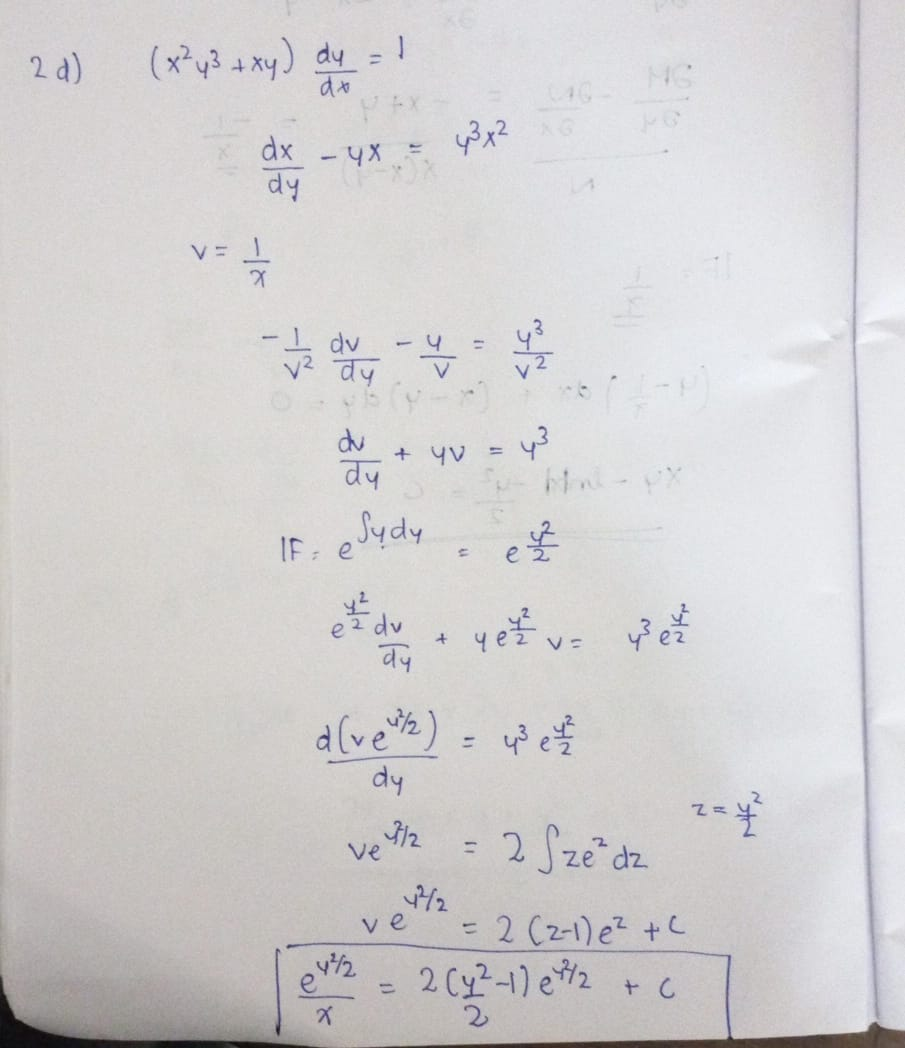

# Q2e

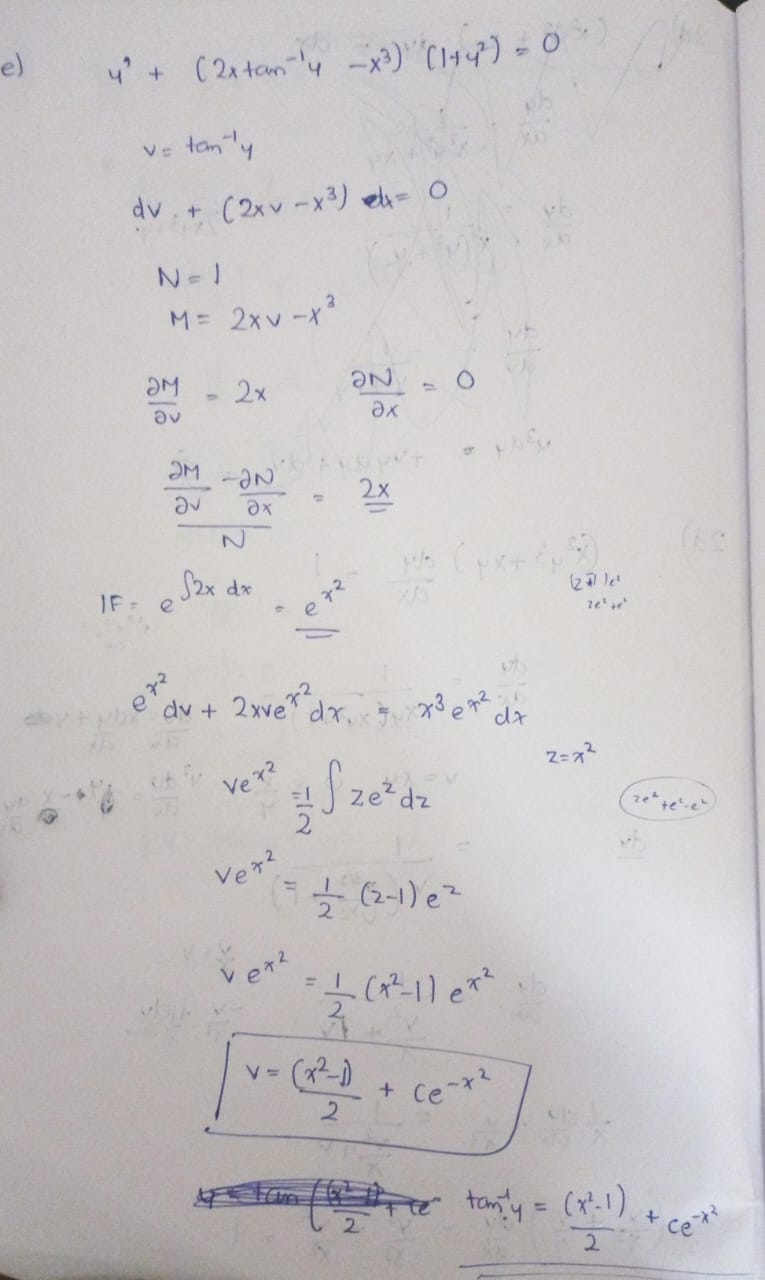

# Q2f

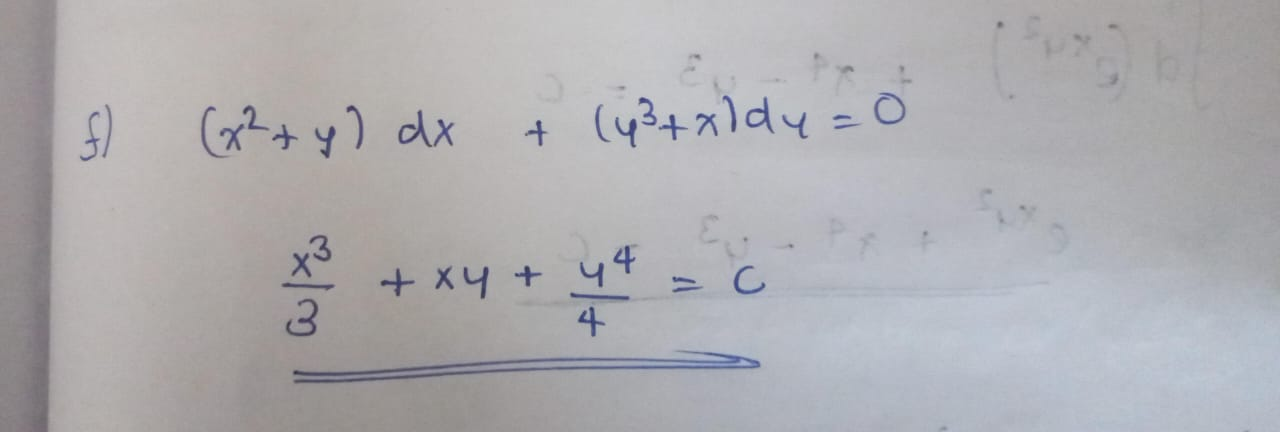

# Q2g

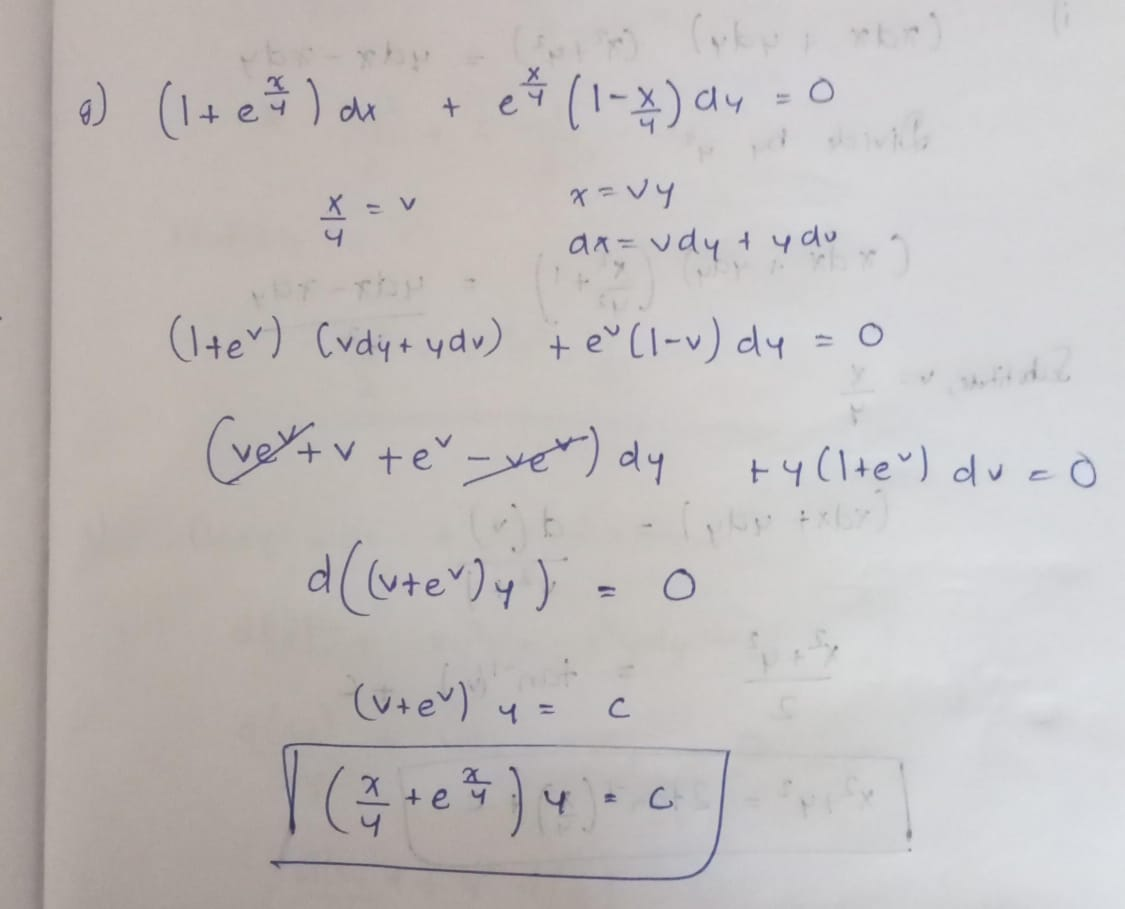

# Q2h

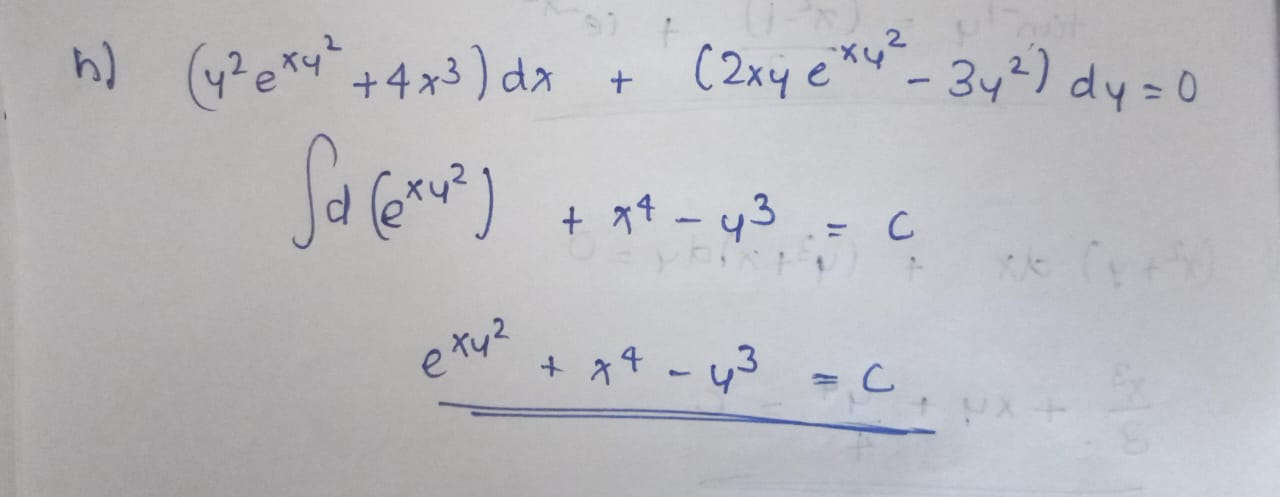

# Q2i

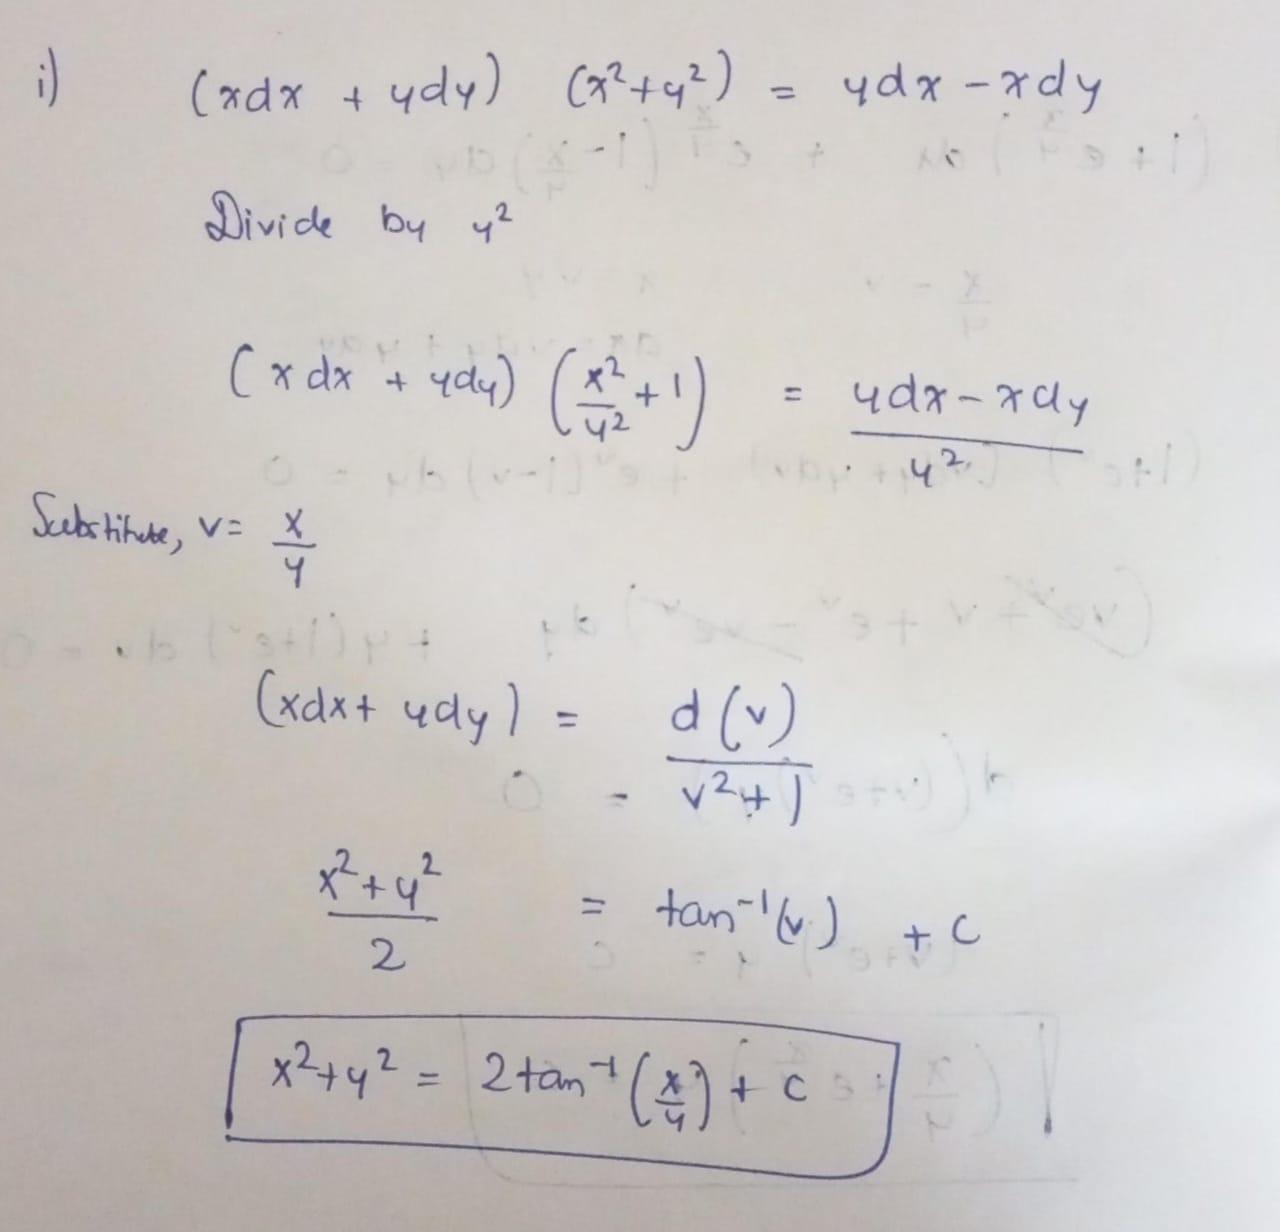

# Q2j

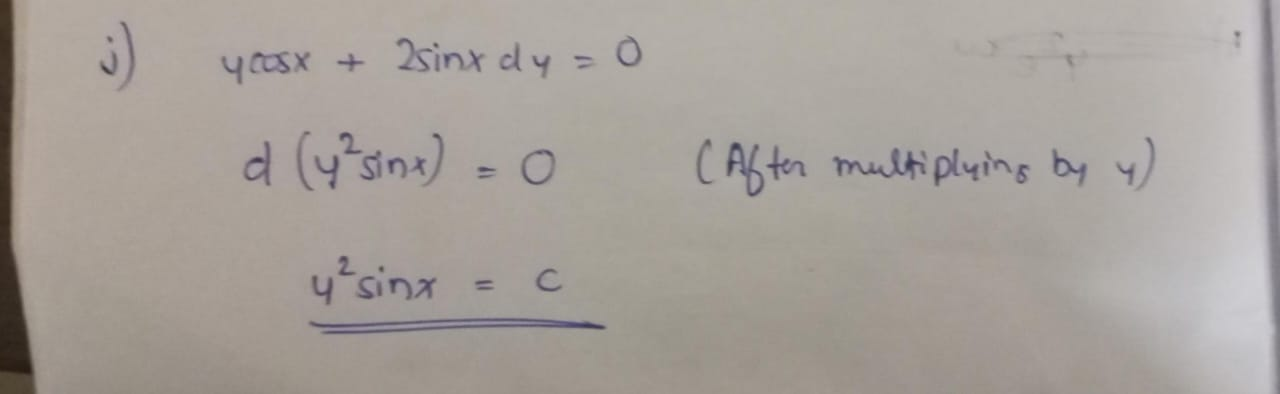

# Q2k

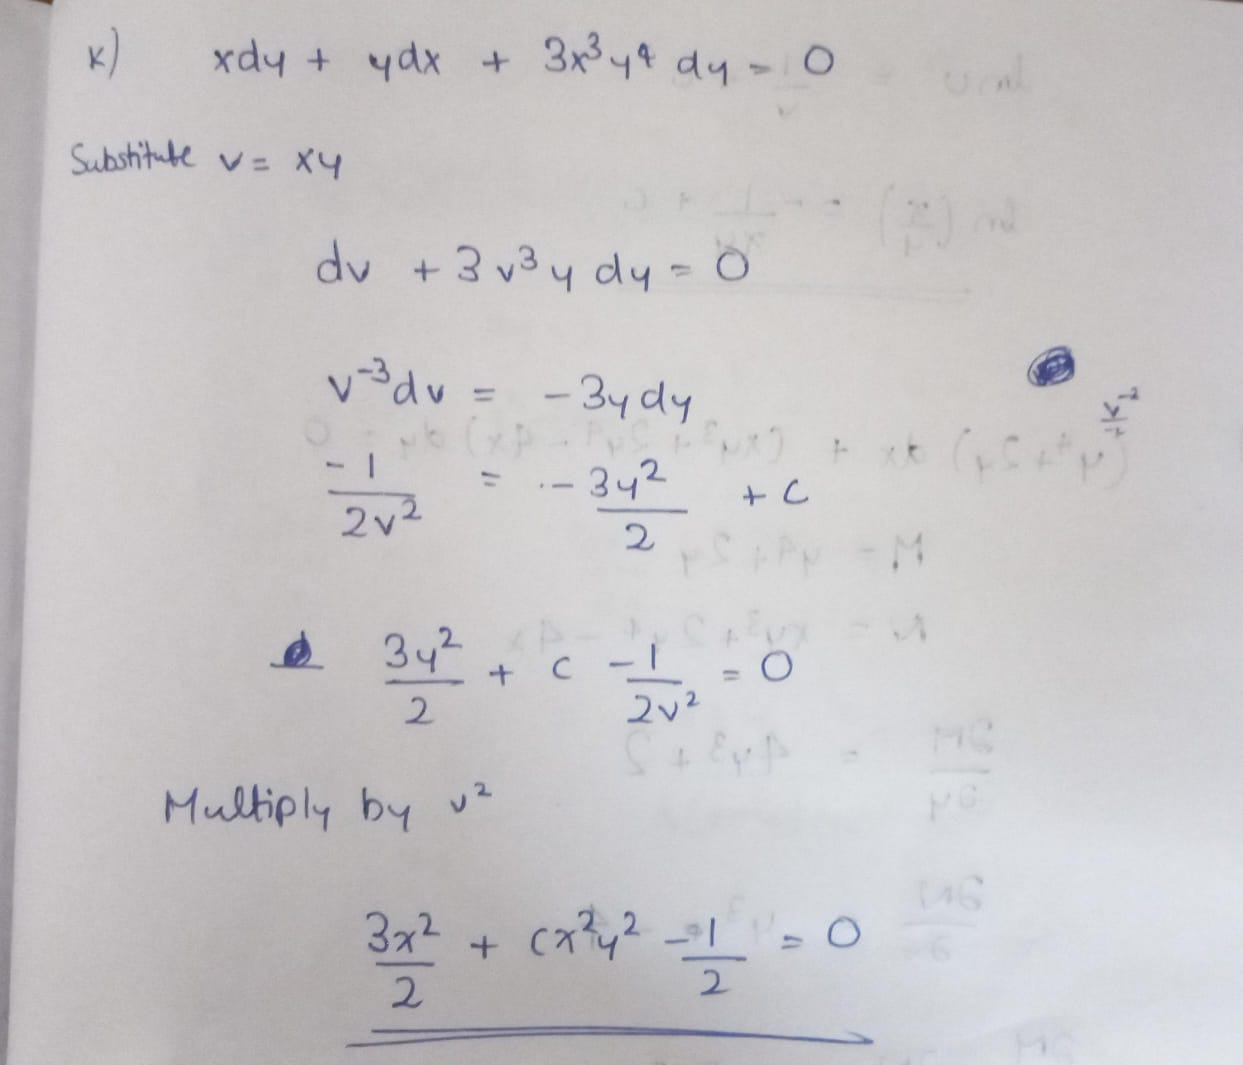

# Q2l

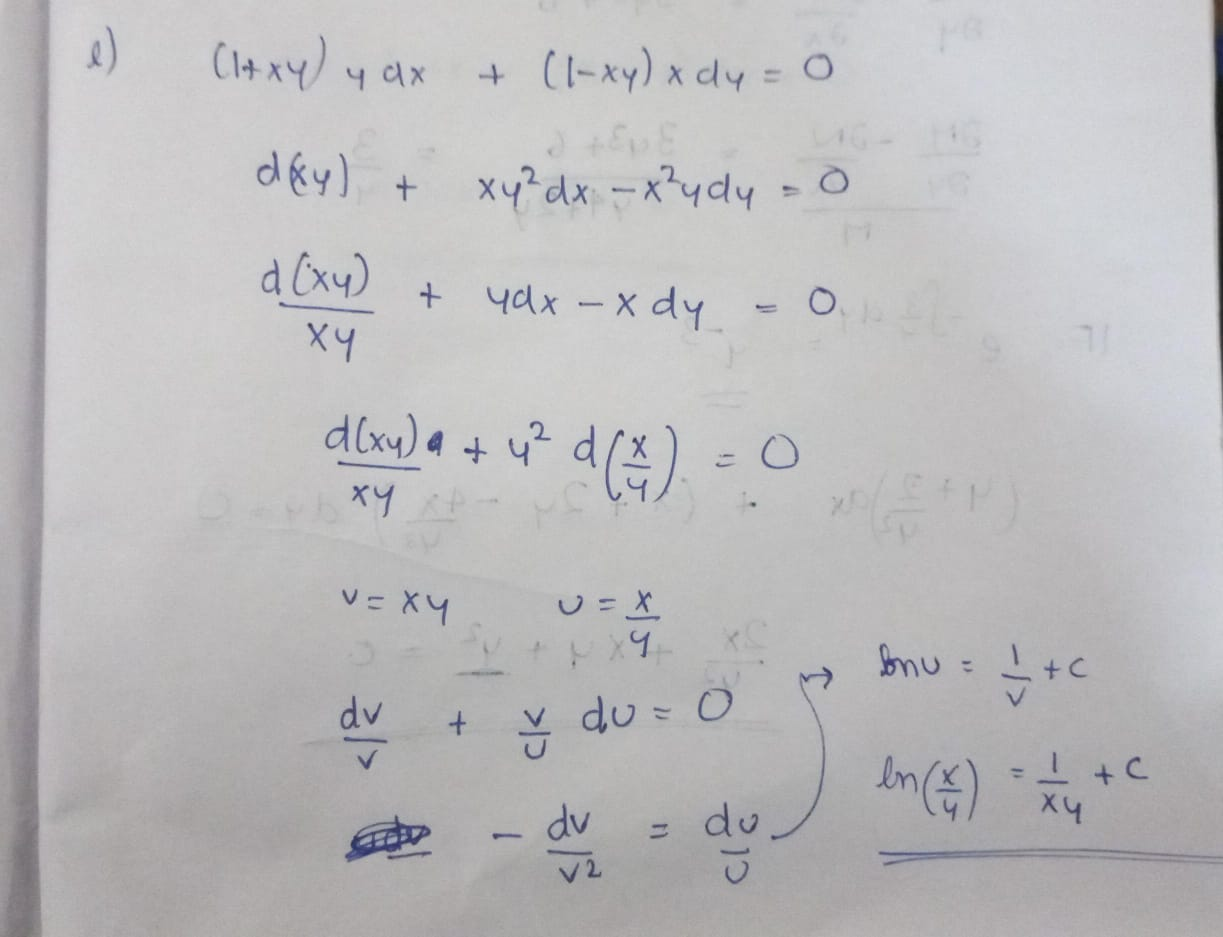

# Q2m

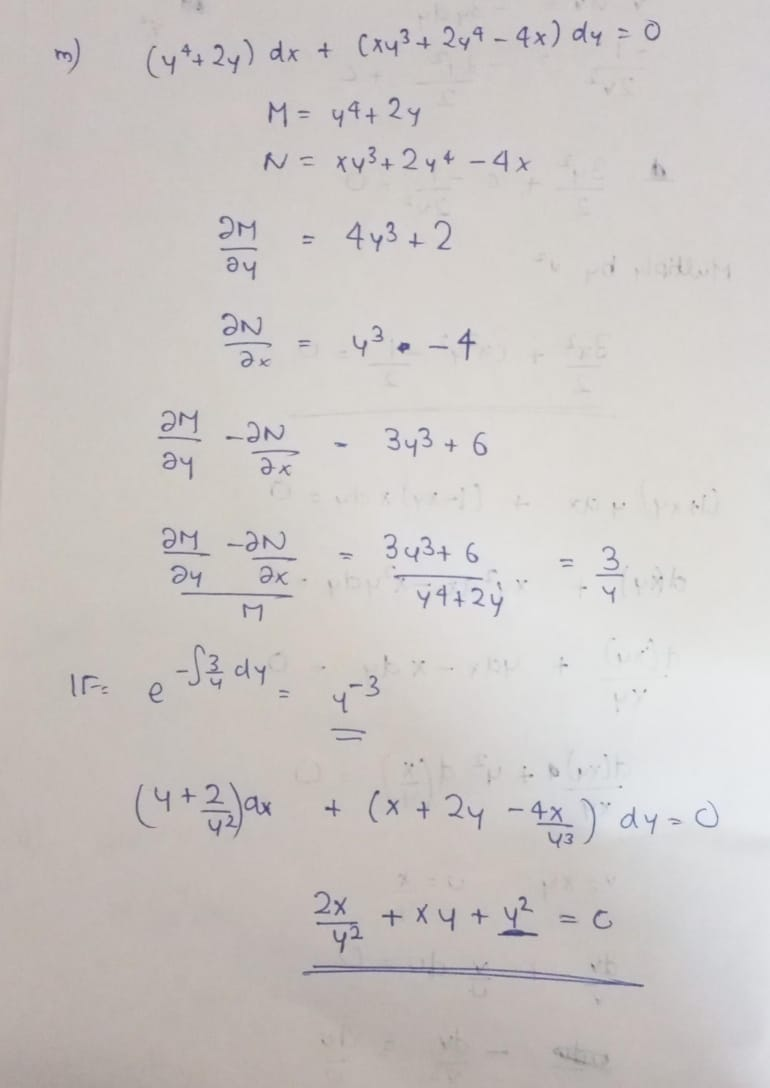

# Q2n

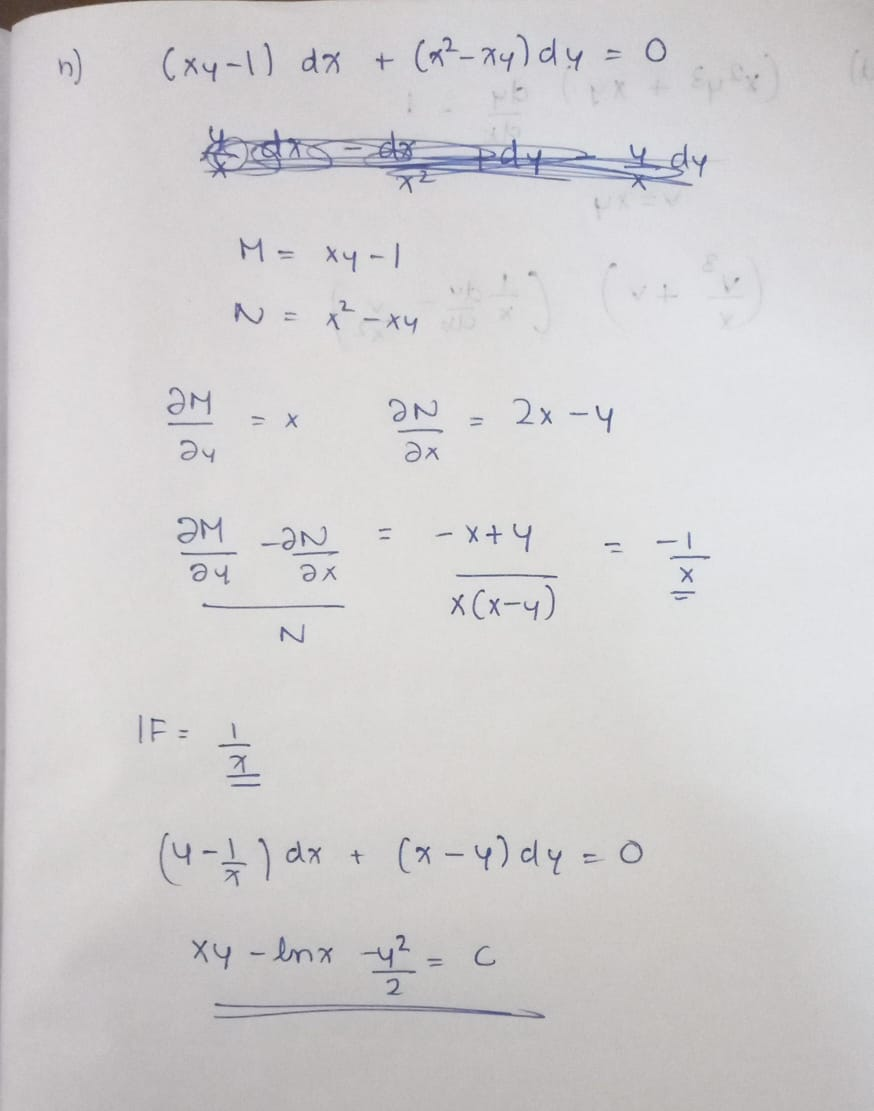

3. Find the curve passing through the point (1, 0) and having at each of its points the slope $-\frac{x}{y}$


# Q3

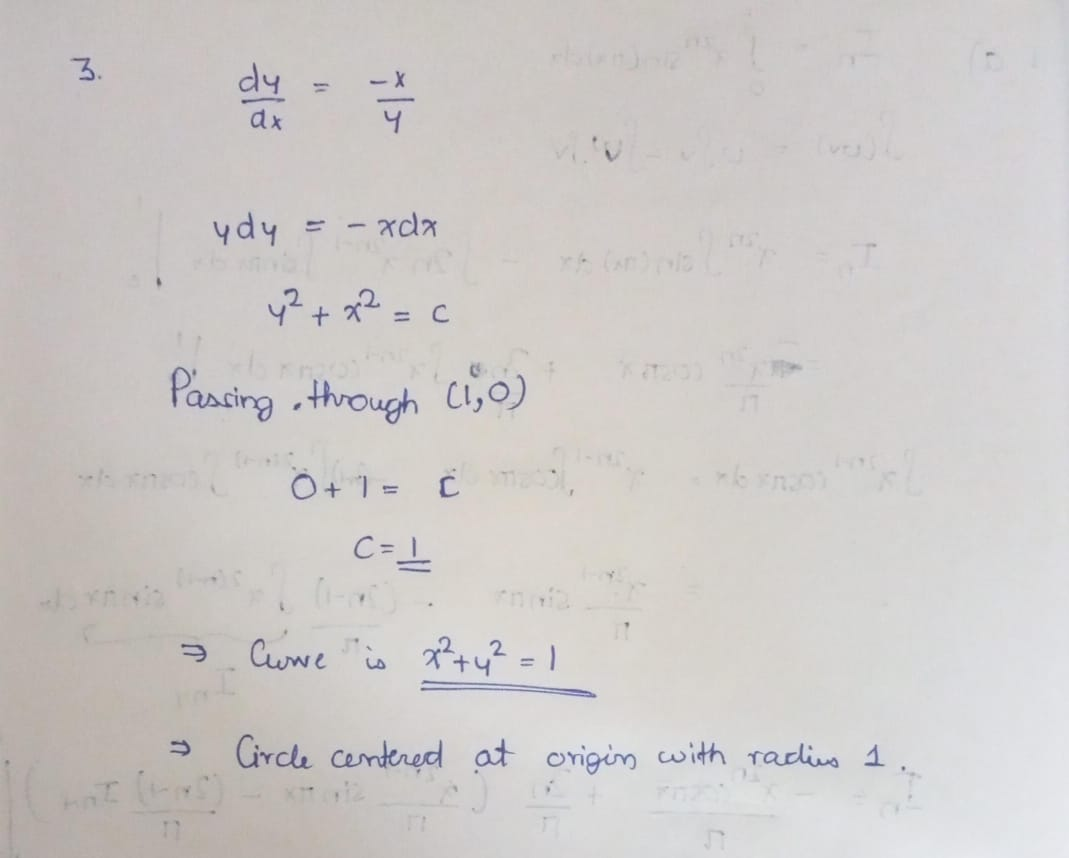

4. Solve the following initial value problem (IVP):
* $\frac{dy}{dx} = 2y + e^{2x}, \quad y(0) = 3$
* $\frac{dy}{dx} = 3y + 2e^{3x}, \quad y(0) = 2$
* $\frac{dy}{dx} = y \tan(x) + \sec(x), \quad y(0) = -1$
* $\frac{dy}{dx} = \frac{2}{x}y + x, \quad y(1) = 2$

# Q4a,4b

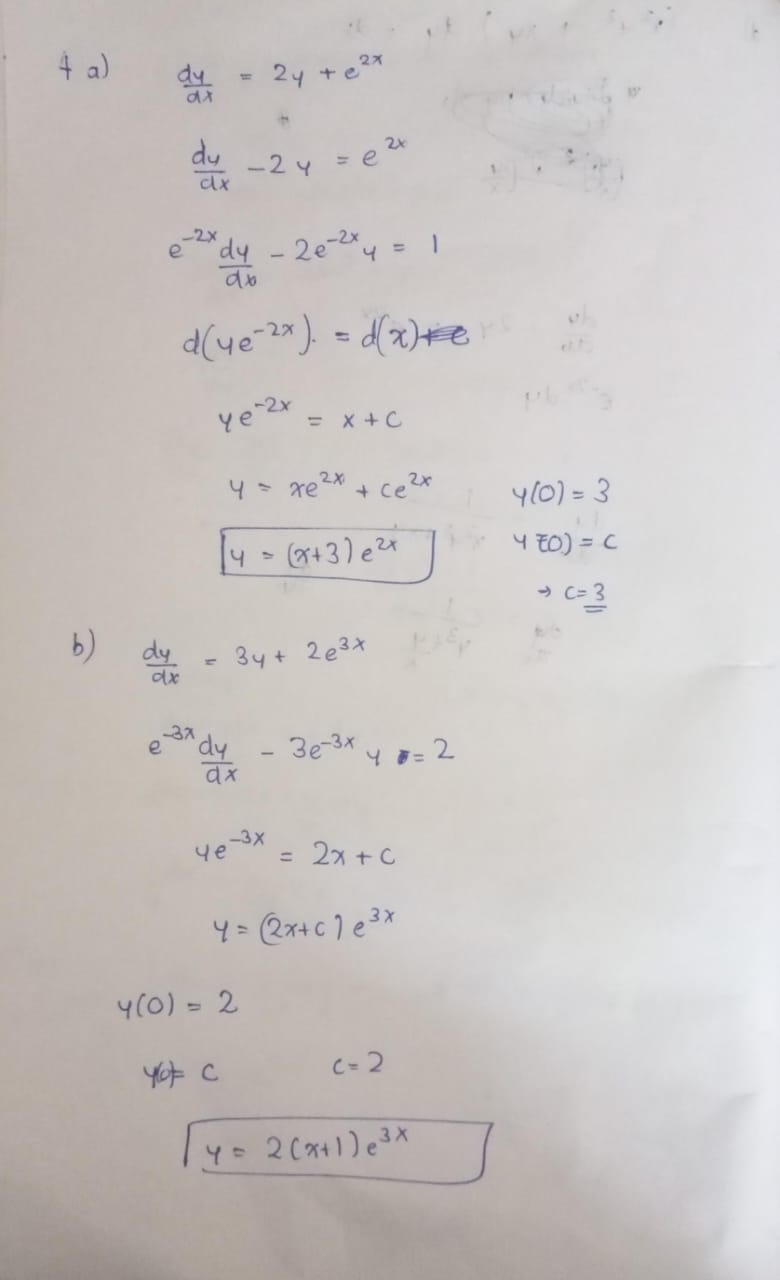

# Q4c

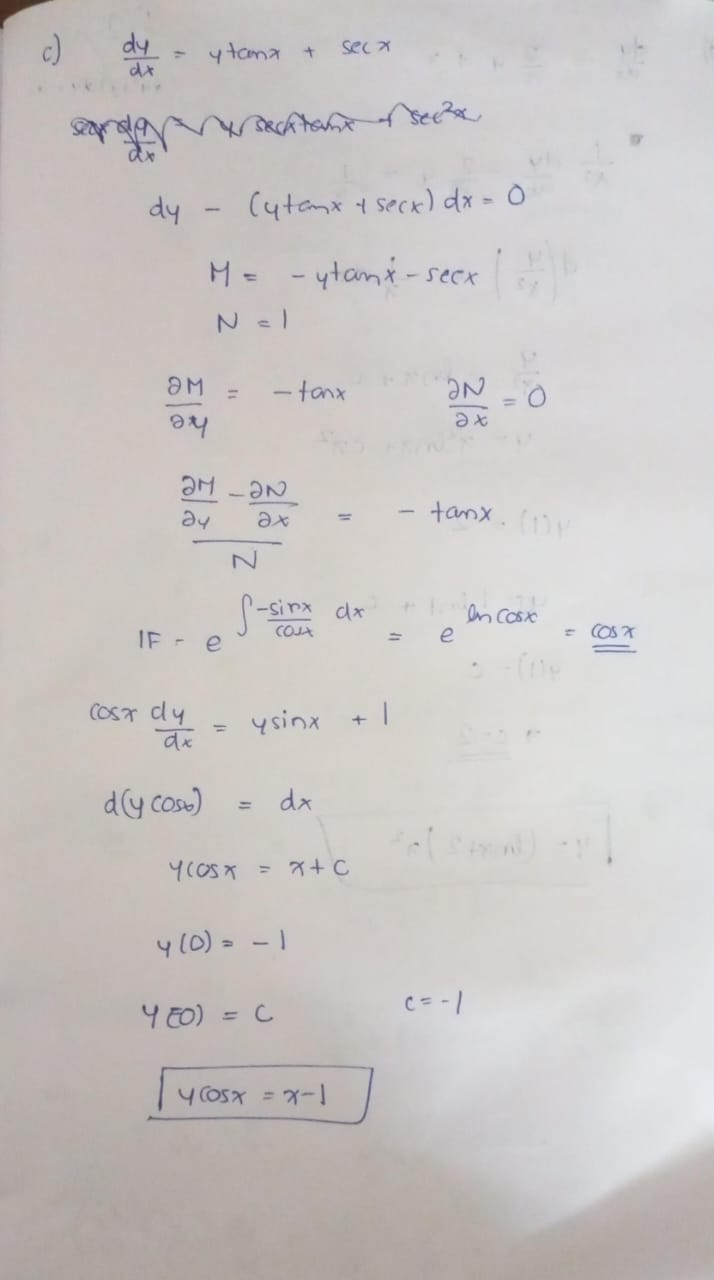

# Q4d

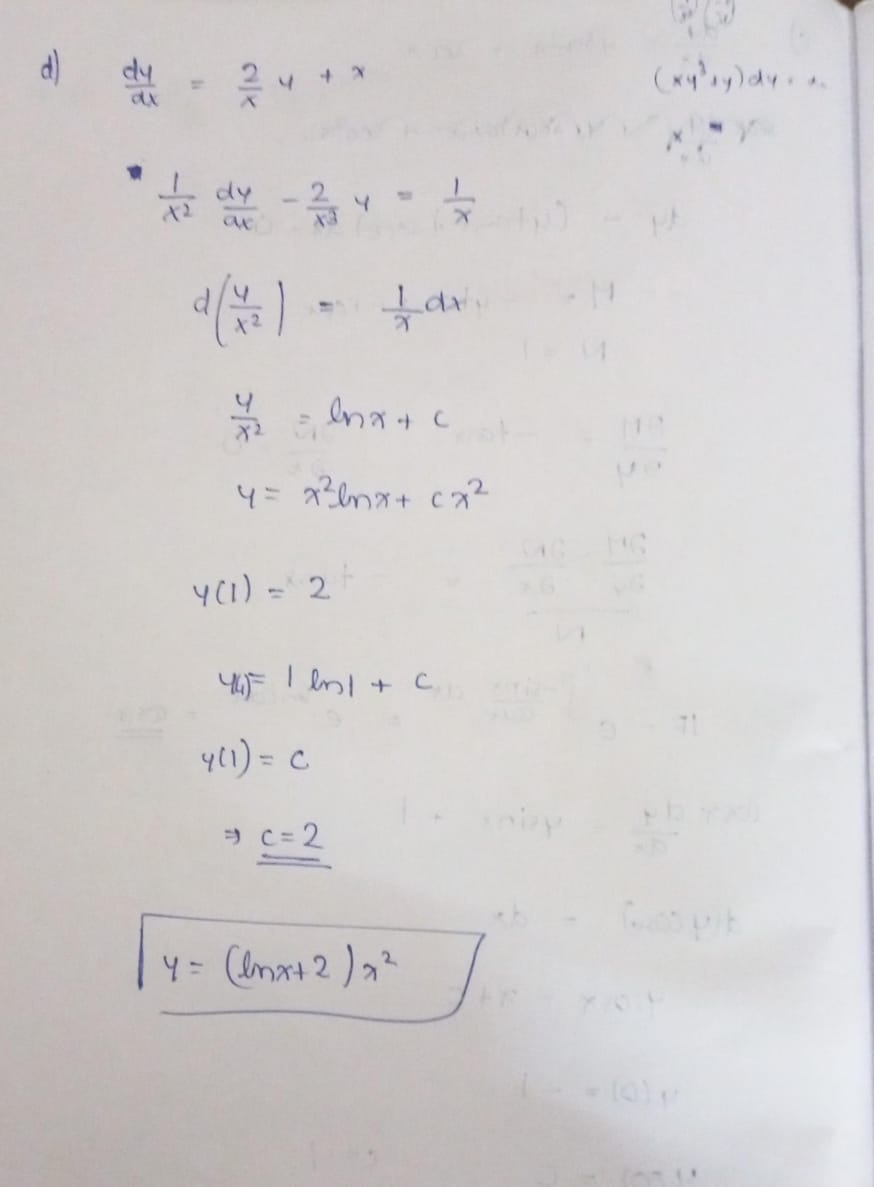